In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
start = '2012-01-01'
end = '2022-12-21'
stock = 'GOOG'
data = yf.download(stock, start, end)

C:\Users\pc\AppData\Local\Temp\ipykernel_3916\768675136.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed


In [3]:
data.reset_index(inplace = True)

In [4]:
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG
0,2012-01-03,16.460485,16.528267,16.137910,16.152011,147611217
1,2012-01-04,16.531481,16.580214,16.341993,16.451085,114989399
2,2012-01-05,16.302168,16.424865,16.233398,16.379349,131808205
3,2012-01-06,16.079779,16.326657,16.074088,16.305629,108119746
4,2012-01-09,15.398017,16.005073,15.367589,15.992702,233776981
...,...,...,...,...,...,...
2756,2022-12-14,94.662201,96.559223,93.301517,94.890641,26452900
2757,2022-12-15,90.580132,93.390898,89.815368,92.904231,28298800
2758,2022-12-16,90.242447,91.126397,89.398226,90.580132,48485500


In [5]:
ma_100_days = data.Close.rolling(100).mean()

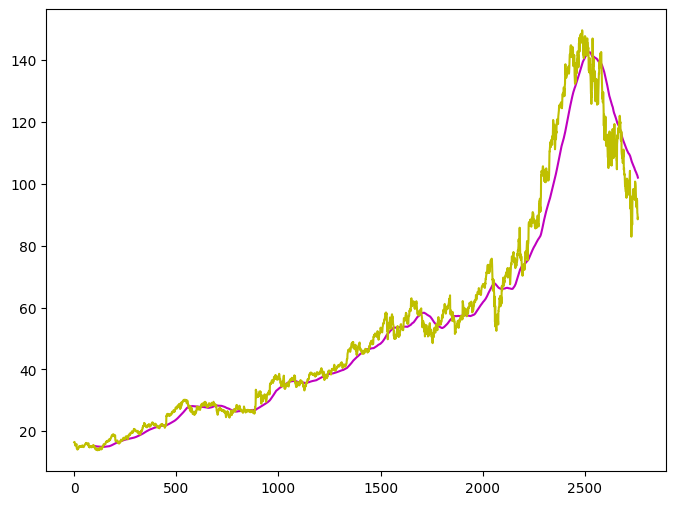

In [6]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days, 'm')
plt.plot(data.Close, 'y')
plt.show()

In [7]:
ma_200_days = data.Close.rolling(200).mean()

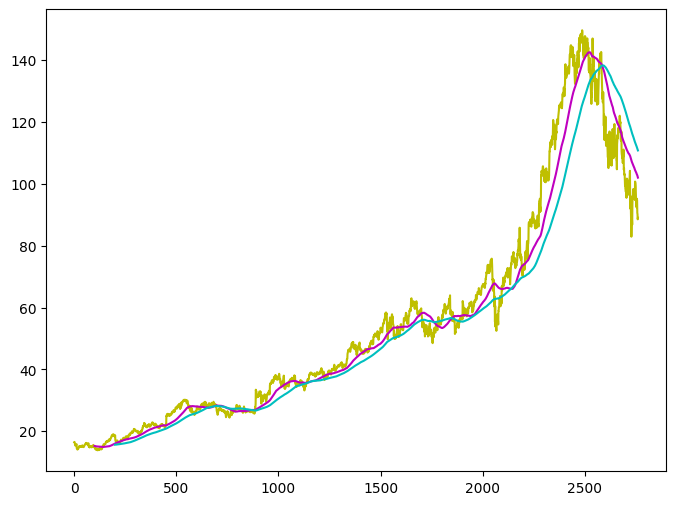

In [8]:
plt.figure(figsize=(8,6))
plt.plot(data.Close, 'y')
plt.plot(ma_100_days, 'm')
plt.plot(ma_200_days, 'c')
plt.show()

data.dropna(inplace = True)

In [9]:
data_train = pd.DataFrame(data.Close[0:int(len(data)*0.8)])
data_test = pd.DataFrame(data.Close[int(len(data)*0.8) : int(len(data))])

In [10]:
data_train.shape[0]

2208

In [11]:
data_test.shape[0]

553

In [12]:
data.shape[0]

2761

In [13]:
!pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [15]:
data_train_scale = scaler.fit_transform(data_train)

In [16]:
x = []
y = []


for i in range(100, data_train_scale.shape[0]) : 
    x.append(data_train_scale[i-100:i])
    y.append(data_train_scale[i,0])

In [17]:
x, y = np.array(x), np.array(y)

In [18]:
!pip install keras

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
from keras.layers import Dense, Dropout,LSTM
from keras.models import Sequential

In [20]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences = True ,
               input_shape = ((x.shape[1],1))))
model.add(Dropout(0.2))


model.add(LSTM(units = 60, activation = 'relu', return_sequences = True ))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True ))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
x.shape[0]

2108

In [22]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [26]:
model.fit(x,y, epochs = 50, batch_size =32, verbose =1)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 36s 548ms/step - loss: 0.0039
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 38s 502ms/step - loss: 0.0039
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 43s 535ms/step - loss: 0.0033
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 512ms/step - loss: 0.0035
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 39s 477ms/step - loss: 0.0034
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 470ms/step - loss: 0.0029
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 463ms/step - loss: 0.0031
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 454ms/step - loss: 0.0026
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 42s 462ms/step - loss: 0.0030
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 464ms/step - loss: 0.0027
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 462ms/step - loss: 0.0030
Epoch 12/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 55s 682ms/step - loss: 0.0028
Epoch 13/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 77s 589ms/step - loss: 0.0026
Epoch 14/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 36s 512ms/step - loss: 0.0030
Epoch 15/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 

In [ ]:
model.summary()

In [27]:
pas_day_100 = data_train.tail(100)

In [28]:
data_test = pd.concat([pas_day_100,data_test], ignore_index = True)


In [29]:
data_test_scale = scaler.fit_transform(data_test)

In [30]:
x = []
y = []

for i in range(100, data_test_scale.shape[0]):
    x.append(data_test_scale[i-100:i])
    y.append(data_test_scale[i,0])
x, y = np.array(x), np.array(y)

In [31]:
y_predict = model.predict(x)

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 214ms/step


In [32]:
scale = 1/scaler.scale_

In [34]:
y_predict = y_predict*scale

In [35]:
y = y*scale

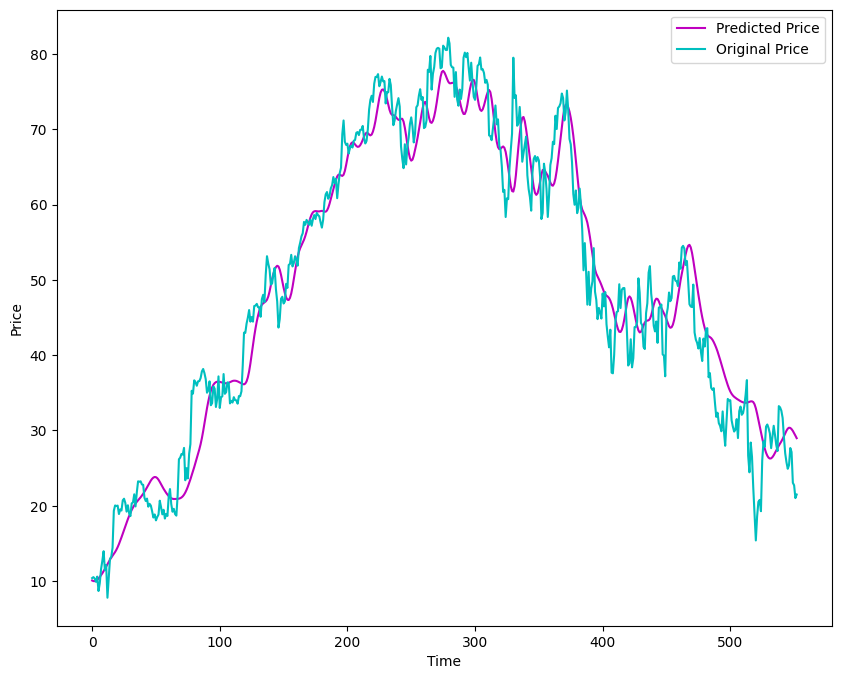

In [36]:
plt.figure(figsize=(10,8))
plt.plot(y_predict, 'm', label = 'Predicted Price')
plt.plot(y, 'c', label = 'Original Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


In [40]:
model.save('Stock Predictions Model.keras')